In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load Data
df = pd.read_csv('fraud_data_cleanned.csv')
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,CUST_1001,64,Male,Germany,112.85,9,73,0,Electronics,50.5,51,0.37,1569
1,CUST_1001,35,Male,UK,252.38,13,224,0,Fashion,86.8,99,0.15,2193
2,CUST_1002,40,Female,Germany,90.38,7,255,1,Beauty,63.4,92,0.10,2215
3,CUST_1004,73,Female,Germany,94.98,9,150,0,Fashion,32.0,49,0.20,2185
4,CUST_1005,43,Male,USA,27.50,10,150,0,Beauty,76.6,13,0.14,1037


In [2]:
print("Shape:", df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Target Class Distribution ---")
print(df['is_fraudulent'].value_counts(normalize=True) * 100)


Shape: (5000, 13)

--- Missing Values ---
customer_id             0
age                     0
gender                  0
country                 0
avg_order_value         0
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate         0
loyalty_score           0
churn_risk              0
customer_tenure_days    0
dtype: int64

--- Target Class Distribution ---
is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64


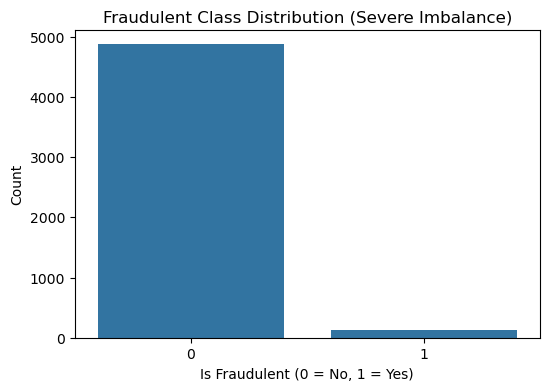

In [3]:
# target ka graph bhi bana kr dekh lete hain
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraudulent', data=df)
plt.title('Fraudulent Class Distribution (Severe Imbalance)')
plt.xlabel('Is Fraudulent (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [4]:
X = df.drop(columns=['customer_id', 'is_fraudulent'])
y = df['is_fraudulent']

In [5]:
# let enode and fix something before puting 
# in making it ready for machine laerning

num_col = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = ['gender', 'country', 'preferred_category']

In [6]:
print('numerical columns' , num_col)
print('categorcal columns' , cat_col)

numerical columns ['age', 'avg_order_value', 'total_orders', 'last_purchase', 'email_open_rate', 'loyalty_score', 'churn_risk', 'customer_tenure_days']
categorcal columns ['gender', 'country', 'preferred_category']


Sclaler transformaiton ki ha mane yahan

In [7]:
# 1. Scale numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_col])




In [8]:
# DataFrame format me convert karein
df_num_scaled = pd.DataFrame(X_num_scaled, columns=num_col, index=X.index)
df_num_scaled.head()

,age,avg_order_value,total_orders,last_purchase,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,0.885776,0.076491,-0.324638,-1.020561,-0.007990,0.033320,0.535566,0.470745
1,-0.736238,2.140960,0.939775,0.418685,1.272028,1.698295,-0.842241,1.648471
2,-0.456580,-0.255972,-0.956845,0.714160,0.446892,1.455486,-1.155378,1.689993
3,1.389160,-0.187911,-0.324638,-0.286641,-0.660341,-0.036054,-0.529103,1.633372
4,-0.288786,-1.186336,-0.008535,-0.286641,0.912353,-1.284785,-0.904868,-0.533341


In [11]:
# df_num_scaled.to_csv('readyforML.csv', index=False)

In [39]:
# 2. Encode categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X[cat_col])

In [64]:
cat_encoded_cols = encoder.get_feature_names_out(cat_col)
df_cat_encoded_cols = pd.DataFrame(X_cat_encoded, columns=cat_encoded_cols, index=X.index)

In [65]:
df_cat_encoded_cols.head()

,gender_Male,gender_Other,country_Brazil,country_Canada,country_China,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,preferred_category_Electronics,preferred_category_Fashion,preferred_category_Home,preferred_category_Sports
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### yeh bohat he mushkil ho raha tha becuase cheezain bhol rahe the hum bar bar

In [44]:
# Manually dono DataFrames ko combine karein
X_preprocessed = pd.concat([df_num_scaled, df_cat_encoded_cols], axis=1)
X_preprocessed.head()

,age,avg_order_value,total_orders,last_purchase,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.885776,0.076491,-0.324638,-1.020561,-0.007990,0.033320,0.535566,0.470745,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.736238,2.140960,0.939775,0.418685,1.272028,1.698295,-0.842241,1.648471,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.456580,-0.255972,-0.956845,0.714160,0.446892,1.455486,-1.155378,1.689993,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.389160,-0.187911,-0.324638,-0.286641,-0.660341,-0.036054,-0.529103,1.633372,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.288786,-1.186336,-0.008535,-0.286641,0.912353,-1.284785,-0.904868,-0.533341,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Train Test split (my fav)

In [45]:
X_train, X_test , y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.20, random_state=42, stratify=y)

In [46]:
# SMOTE apply krna hai
smote = SMOTE(random_state=42)

# smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [49]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [50]:
# smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [51]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: is_fraudulent
0    3897
1     103
Name: count, dtype: int64
After SMOTE: is_fraudulent
0    3897
1    3897
Name: count, dtype: int64


In [52]:
rf = RandomForestClassifier()

In [68]:
rf.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
y_pred_rf = rf.predict(X_test)

In [70]:
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))



=== Confusion Matrix ===
[[974   0]
 [ 26   0]]


In [71]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



In [ ]:
df = pd.read_csv('fraud_data_cleanned.csv')
df.head(5)

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,800
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,907
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,850
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,2228
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,492


In [57]:
print(classification_report(y_test, y_pred_rf_train))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



/home/murtaza-ali/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/murtaza-ali/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/murtaza-ali/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [58]:
rf.fit(X_test, y_test)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred_rf_test = rf.predict(X_train)

In [63]:
# Use the model trained on resampled data to predict on test set
y_pred_rf_test = rf.predict(X_test)

# Compare with actual test labels
print(classification_report(y_test, y_pred_rf_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       974
           1       1.00      1.00      1.00        26

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## Jaisa k mane eik model ka sara method likh lia hai ab main inko eik sath likh kr eik jaga kr raha hun for better understanding and evaluations

In [73]:
# 1. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)
print("--- Decision Tree Report ---")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# 2. XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)
print("--- XGBoost Report ---")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

# 3. RandomForest
rf = RandomForestClassifier()
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
print("---Random Forest---")
print(classification_report(y_pred_rf, y_test))


--- Decision Tree Report ---
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       974
           1       0.03      0.19      0.06        26

    accuracy                           0.84      1000
   macro avg       0.50      0.52      0.48      1000
weighted avg       0.95      0.84      0.89      1000

--- XGBoost Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       974
           1       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000

---Random Forest---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1000
           1       0.00      0.00      0.00         0

    accuracy                           0.97      1000
   macro avg       0.50      0.49      0.49      1000
we

/home/murtaza-ali/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/murtaza-ali/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/murtaza-ali/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
